# Clasificación de audios
En este notebook vamos a probar varios modelos para clasificar los audios en reales y generados según las características y los audios.

## 1 Imports

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np
import json

## 2 Preparar los datos

In [2]:
SPOOF = "Features\\spoof_features.csv"
BONAFIDE = 'Features\\bonafide_features.csv'

RANDOM_STATE = 12

In [3]:
df_spoof = pd.read_csv(SPOOF)
df_bonafide = pd.read_csv(BONAFIDE)

In [4]:
df = pd.concat([df_spoof, df_bonafide], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [5]:
df['pitch'] = df['pitch'].apply(lambda x: np.array(json.loads(x)))
df['f1'] = df['f1'].apply(lambda x: json.loads(x))
df['f2'] = df['f2'].apply(lambda x: json.loads(x))
df['f3'] = df['f3'].apply(lambda x: json.loads(x))
for col in df.columns:
    if 'mfcc' in col and not col.endswith('mean'):
        df[col] = df[col].apply(lambda x: np.array(json.loads(x)))

In [6]:
df = df.drop(['pitch', 'f1', 'f2', 'f3'], axis=1)
mfcc_cols = [c for c in df.columns if c.startswith('mfcc') and not c.endswith('mean')]
df = df.drop(mfcc_cols, axis=1)

In [7]:
df

,filename,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,Dataset\Generado\Español\E_26_G.wav,3.216687,0.051758,0.085643,1254.503350,1326.277329,2563.505569,0.137293,102.351443,6.978547,...,-24.268038,-14.575477,-9.283944,-12.405594,3.906438,-5.953425,-5.590491,-0.694002,4.627871,0
1,Dataset\Generado\Español\E_48_G.wav,2.206625,0.050090,0.114555,1361.571234,1286.077576,2651.041667,0.194745,204.345071,33.738921,...,-16.042852,-5.291547,-8.852230,-12.420032,-7.720528,1.628054,-6.962458,0.200115,3.936875,0
2,Dataset\Natural\Español\E_49_N.wav,3.656000,0.059918,0.136553,1765.967990,1586.161845,3349.796196,0.018546,225.686035,42.079431,...,-17.003986,-5.797369,-16.223082,-9.647523,-6.975890,-2.169085,-6.030098,-0.352658,7.398267,1
3,Dataset\Generado\Español\E_23_G.wav,2.740687,0.052334,0.070074,1044.101842,1137.657301,2086.845930,0.155904,103.726181,17.271786,...,-21.837030,-13.952543,-5.273086,-15.985622,4.532742,-3.402674,-2.512440,-0.610936,3.189704,0
4,Dataset\Natural\Español\E_27_N.wav,2.824063,0.060682,0.099423,1306.290869,1427.197259,2584.708567,0.017563,99.070182,13.325032,...,-36.884580,-17.921293,-10.599140,-3.910789,4.797422,-3.956316,-4.125283,-0.689673,5.315204,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Dataset\Generado\Español\E_13_G.wav,6.281750,0.063773,0.081907,1163.603803,1124.931612,2250.674175,0.076228,121.485683,16.773291,...,-2.402092,-17.969810,-9.149986,-11.105045,-9.460912,-2.077079,-2.921755,-0.963130,3.135151,0
96,Dataset\Generado\Español\E_12_G.wav,3.309563,0.053563,0.090186,1164.858297,1163.522182,2263.146034,0.136308,124.699746,18.706685,...,-3.416033,-14.082165,-9.485531,-9.562201,-7.460647,-0.784725,-3.263623,-0.955104,4.206410,0
97,Dataset\Generado\Español\E_16_G.wav,3.042562,0.048594,0.066966,1047.294232,1053.587620,2068.929036,0.157650,111.482995,23.065551,...,-1.164710,-14.021972,-6.244248,-1.665420,-4.780271,-0.736931,0.065389,-1.620632,9.519138,0
98,Dataset\Generado\Español\E_35_G.wav,3.774000,0.058605,0.147068,1636.921798,1330.756820,2864.870233,0.130687,196.658212,28.452153,...,-9.550146,-7.320043,-12.479050,-10.272341,-0.991668,3.214933,-4.203745,0.296406,4.571232,0


In [8]:
X = df.drop(columns=['label', 'filename'])
y = df['label']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred_rf = rf_model.predict(X_test)

In [13]:
def evauluacion(model_name: str, test, y_pred):
    print(f"=== Evaluación {model_name} ===")
    print(classification_report(test, y_pred))    

In [15]:
evauluacion("Random Forest", y_test, y_pred_rf)

=== Evaluación Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## Support Vector Machine 

In [16]:
svm_model = SVC(
    kernel='rbf',       # Kernel radial, funciona bien en problemas no lineales
    C=1.0,              # Parámetro de regularización
    probability=True,   # Para obtener probabilidades luego
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [18]:
evauluacion("Support Vector Machine", y_test, y_pred_svm)

=== Evaluación Support Vector Machine ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [16]:
import shap
import matplotlib.pyplot as plt

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
y_test = y_test.tolist()
y_test

AttributeError: 'list' object has no attribute 'tolist'

In [28]:
y_test

[0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1]

In [21]:
type(y_pred_rf)

numpy.ndarray

In [29]:
print(f'Valor real del audio: {y_test[0]}')
print(f'Valor predicho del audio: {y_pred_rf[0]}')

Valor real del audio: 0
Valor predicho del audio: 0


In [22]:
explainer_rf = shap.Explainer(rf_model.predict, X_train)
shap_values_rf = explainer_rf(X_test)

PermutationExplainer explainer: 21it [00:13,  1.44it/s]                        


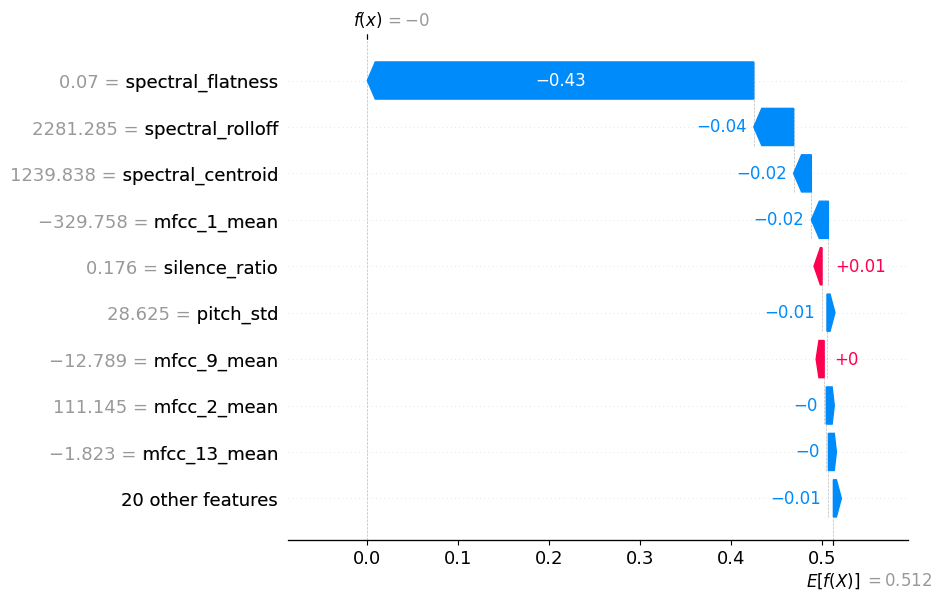

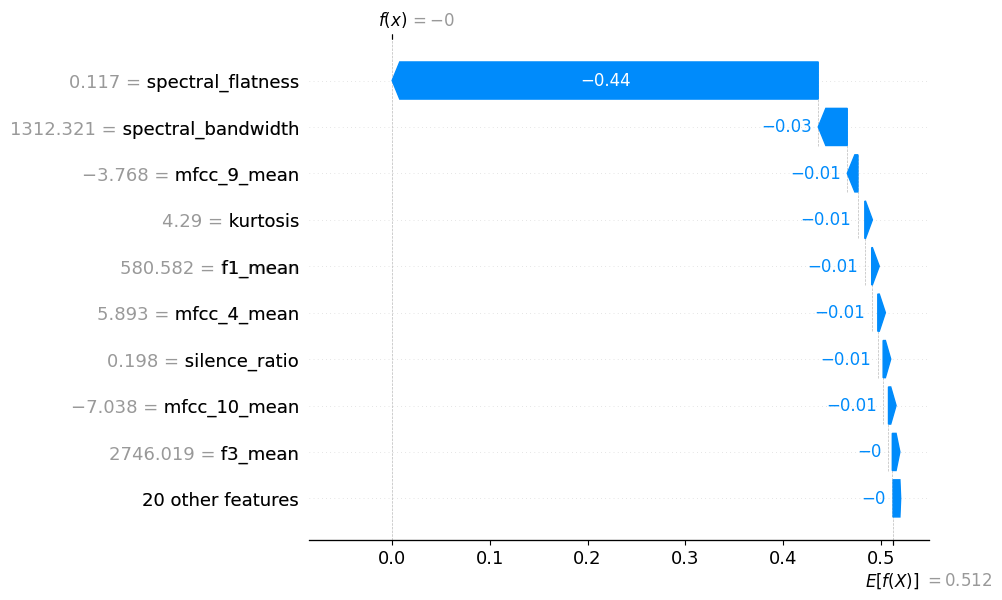

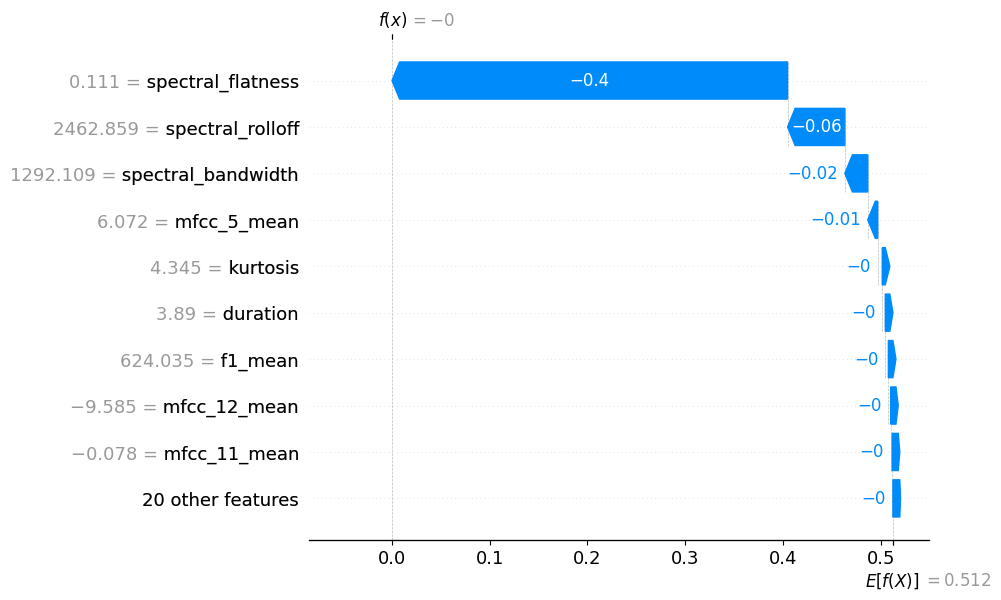

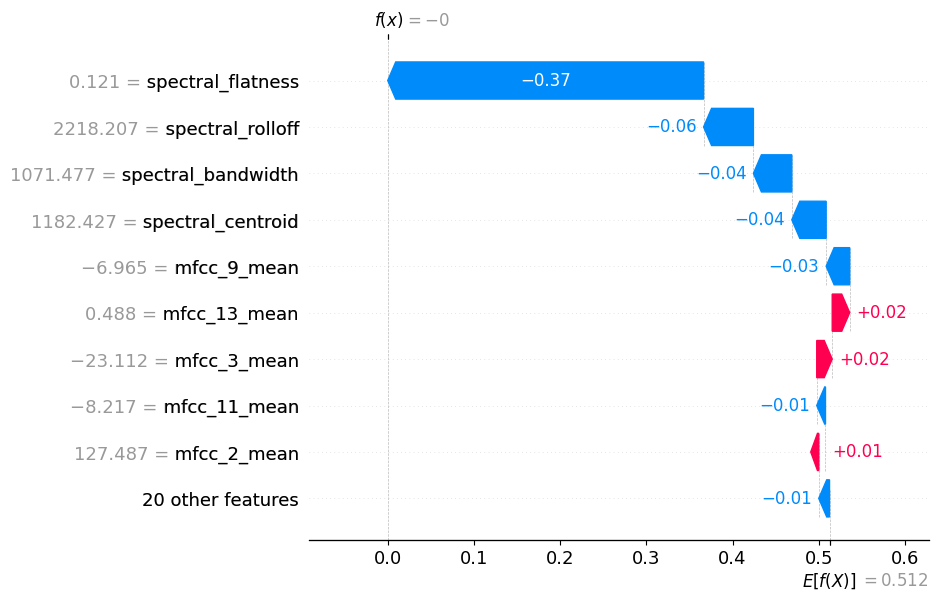

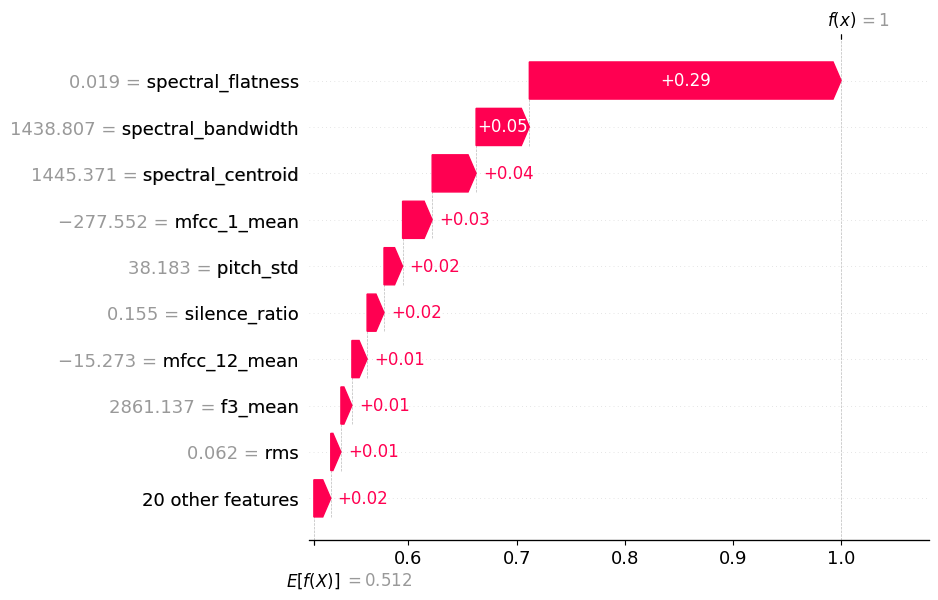

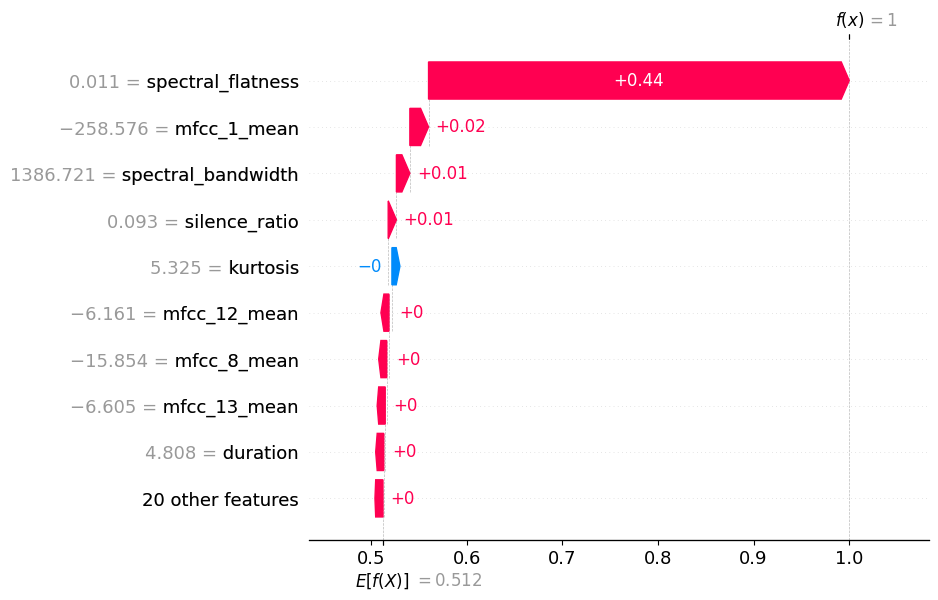

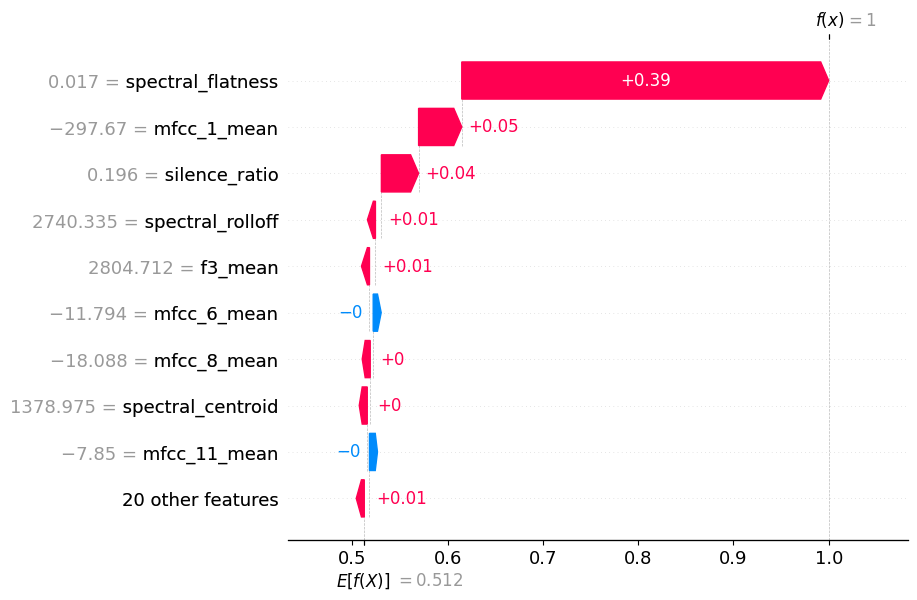

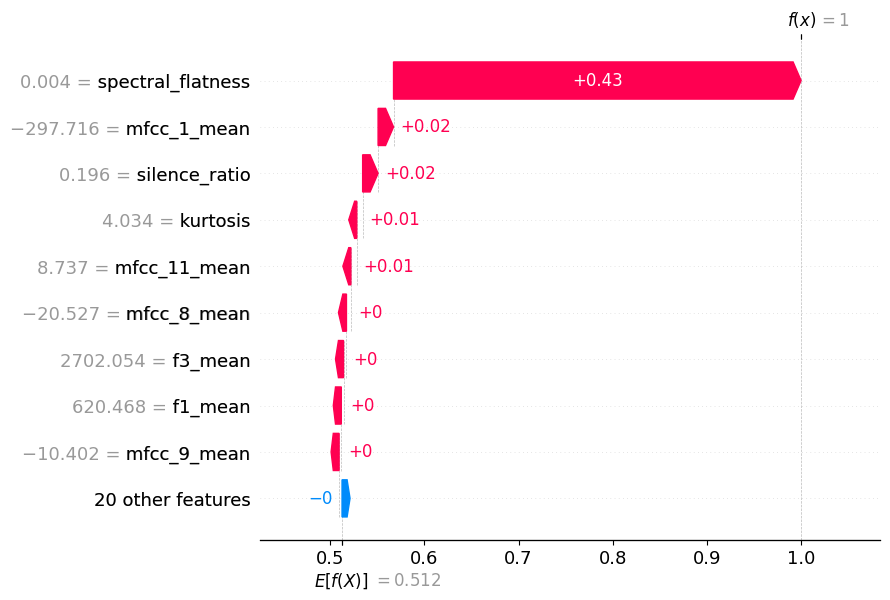

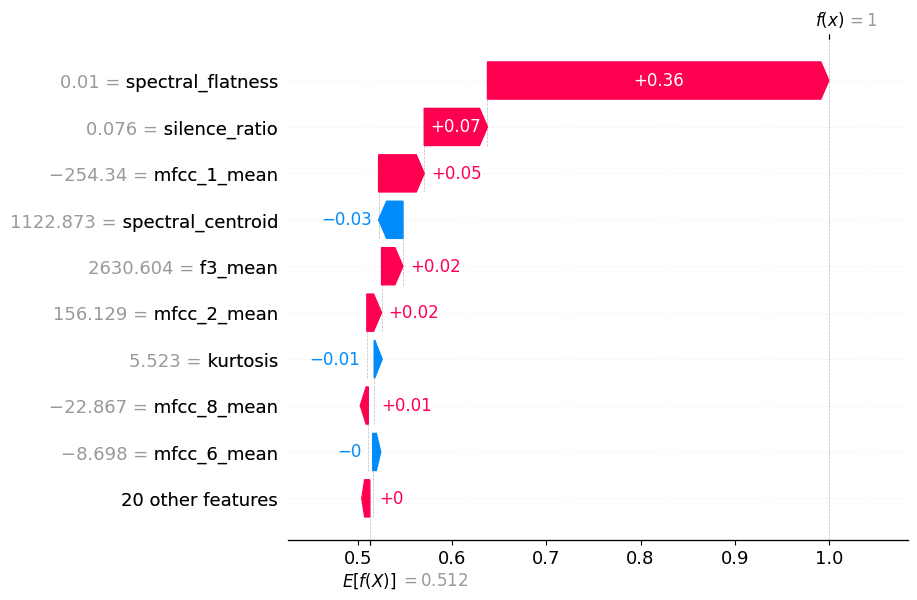

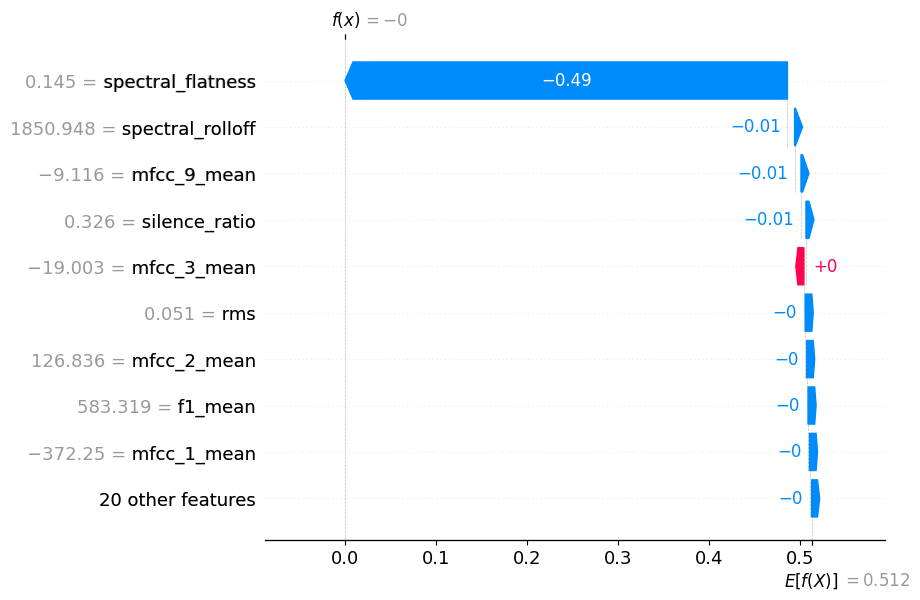

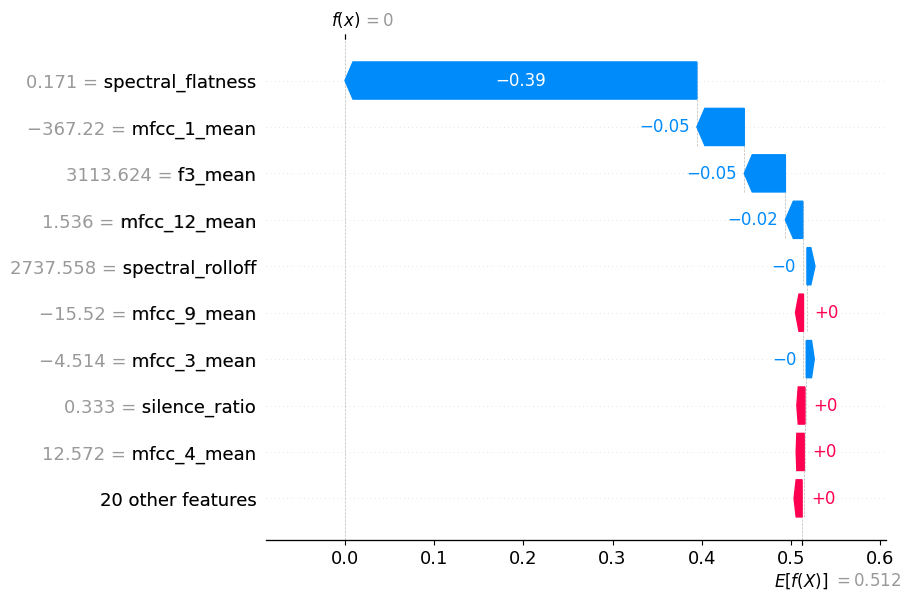

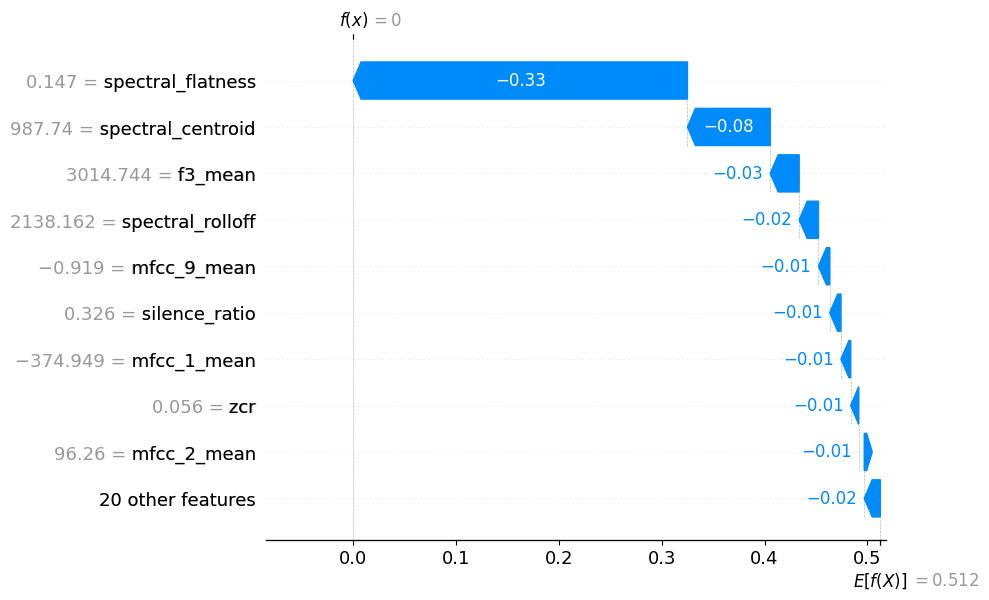

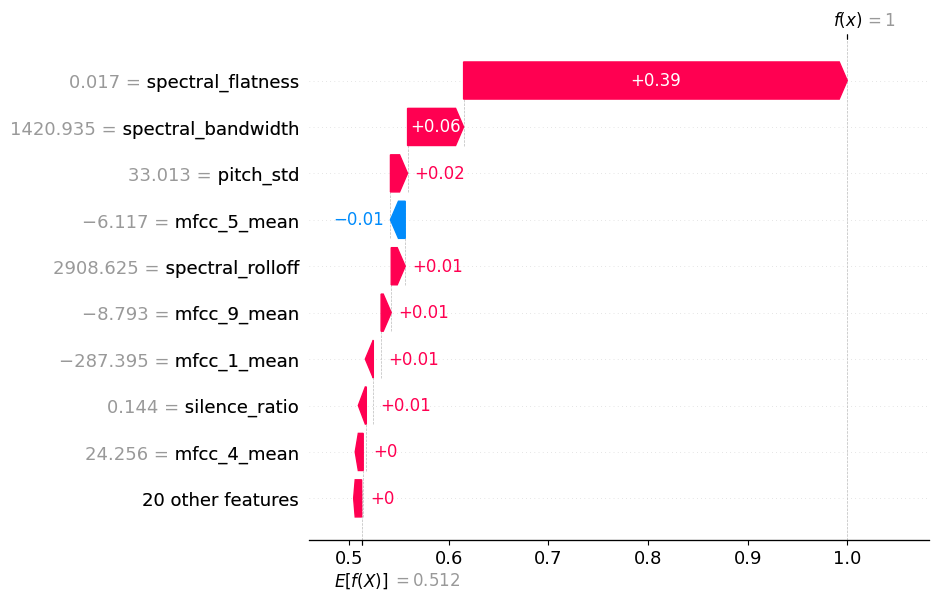

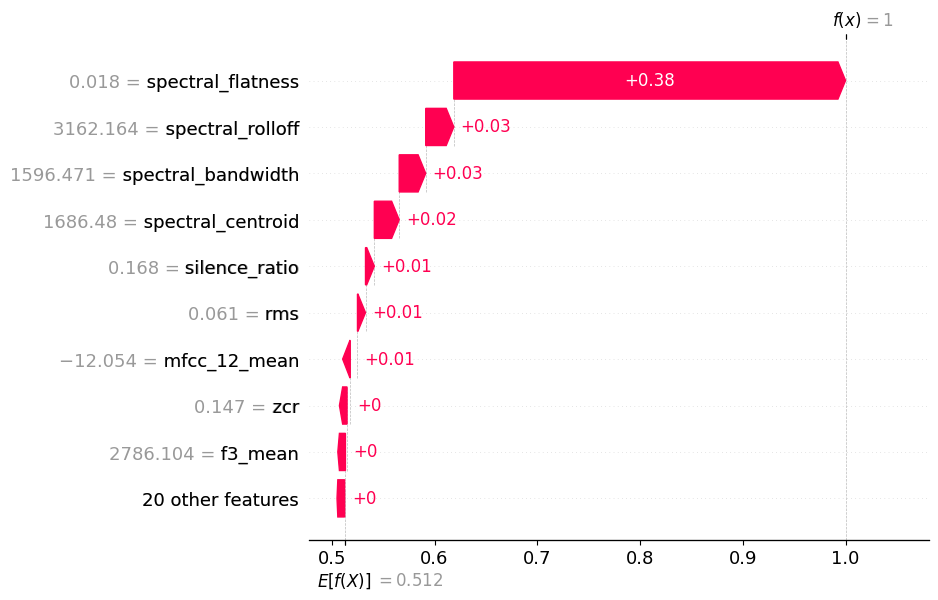

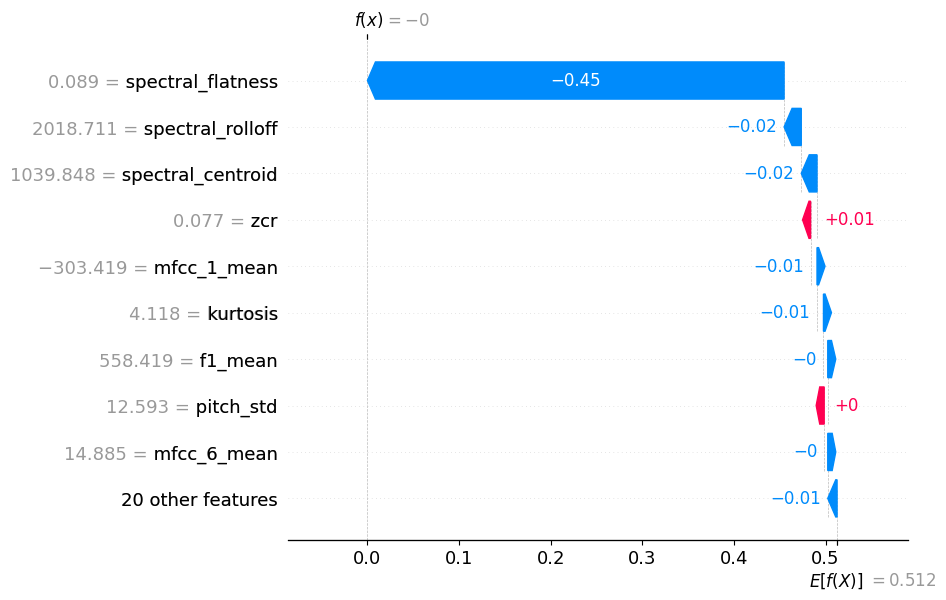

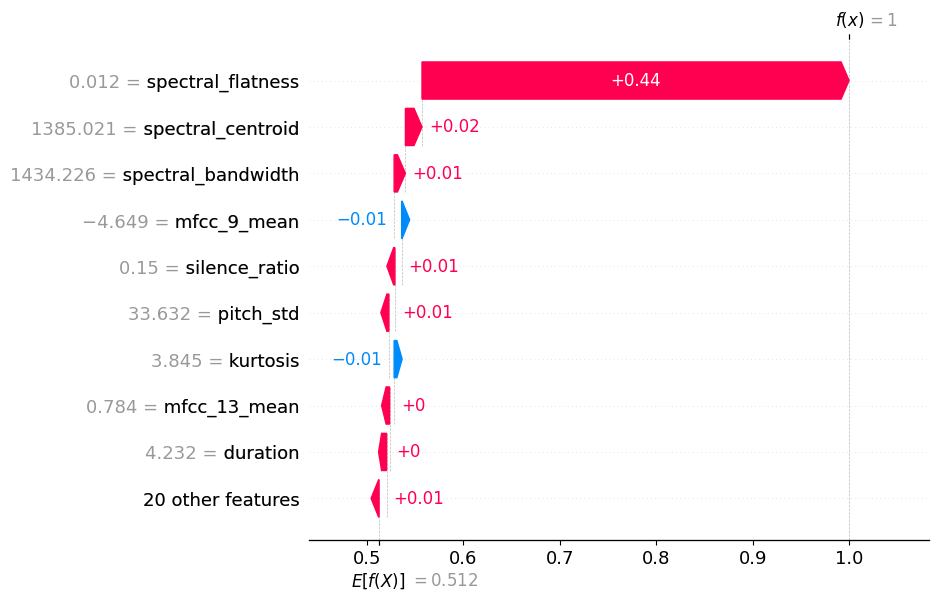

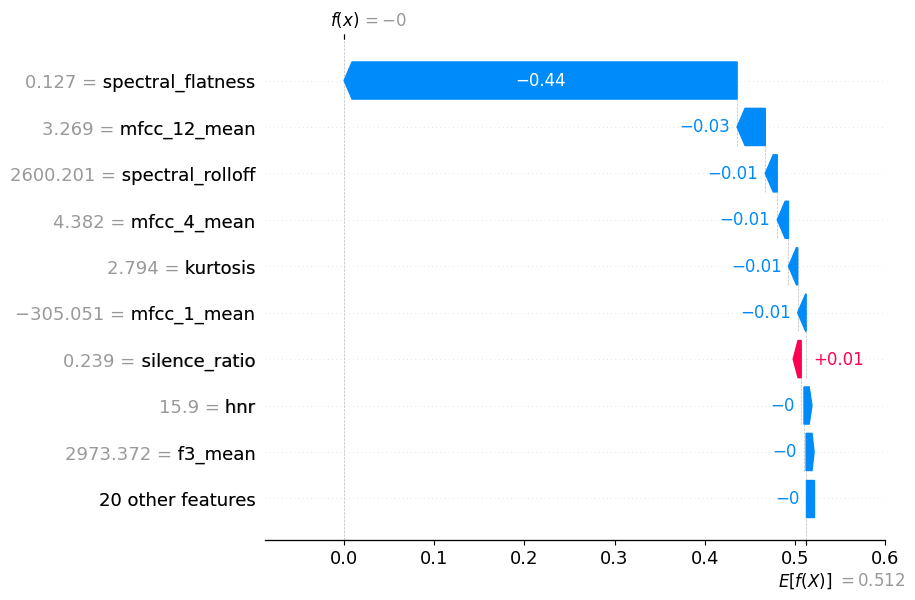

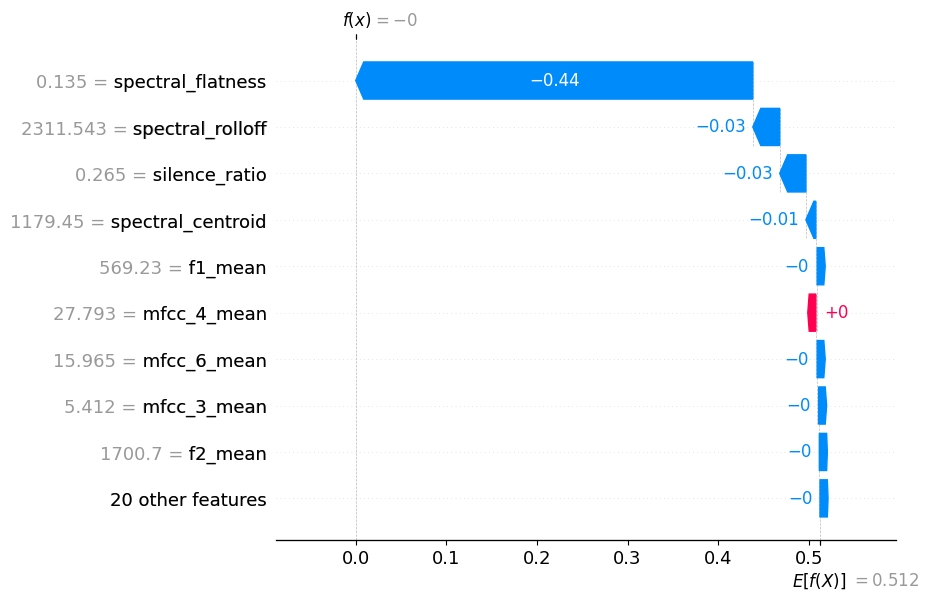

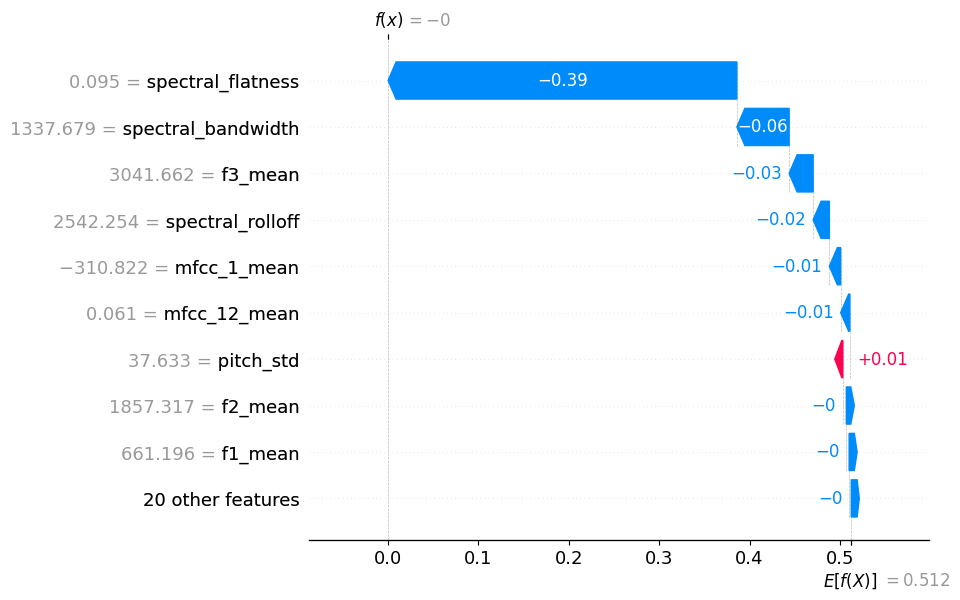

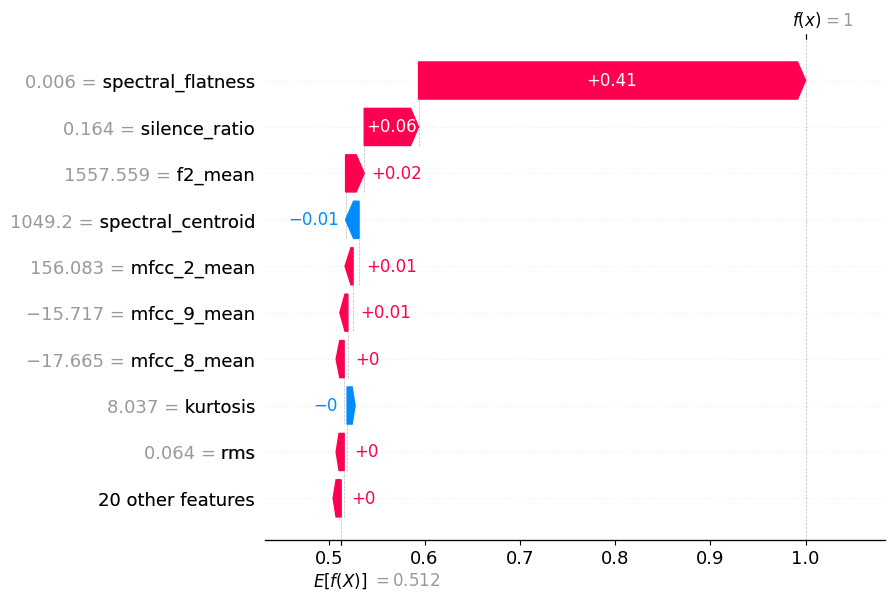

In [24]:
for i in range(20):
    shap.plots.waterfall(shap_values_rf[i])